In [4]:
import os
print(os.listdir("./stock_market_dataset/Stocks")[:10])
print(os.listdir("./stock_market_dataset/ETFs")[:10])

['rlj.us.txt', 'arnc_.us.txt', 'vjet.us.txt', 'snv.us.txt', 'fogo.us.txt', 'xom.us.txt', 'tve.us.txt', 'wmlp.us.txt', 'info.us.txt', 'pkw.us.txt']
['xpp.us.txt', 'slqd.us.txt', 'ezj.us.txt', 'csm.us.txt', 'uge.us.txt', 'iyc.us.txt', 'don.us.txt', 'jjp.us.txt', 'ydiv.us.txt', 'pxmg.us.txt']


In [5]:
import pandas as pd
pddf = pd.read_csv("./stock_market_dataset/ETFs/xpp.us.txt")

In [6]:
pddf.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2009-06-04,59.33,60.39,59.33,60.00,5725,0
1,2009-06-05,63.32,63.32,59.73,61.22,110241,0
2,2009-06-08,60.22,60.22,57.50,59.38,17906,0
3,2009-06-09,58.38,58.84,57.22,58.46,24541,0
4,2009-06-10,62.99,63.11,59.99,61.44,103407,0


In [12]:
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import os
from pathlib import Path


stocks_path = "./stock_market_dataset/Stocks"
etfs_path = "./stock_market_dataset/ETFs"

stock_files = [stocks_path+"/"+path for path in os.listdir(stocks_path)]
etfs_files = [etfs_path+"/"+path for path in os.listdir(etfs_path)]

def read_stocks(file_path):
    try:
        csv =  pd.read_csv(file_path)
        csv["company"] = Path(file_path).name
        csv["type"] = "stock"
        return csv
    except Exception as e:
        print(e)
        return None

stock_files_dfs = []
etfs_files_dfs = []

with ThreadPoolExecutor(max_workers=100) as executor:
    stock_files_dfs = list(executor.map(read_stocks,stock_files))

stock_files_dfs = [file for file in stock_files_dfs if file is not None]

len(stock_files_dfs)

def read_etfs(file_path):
    try:
        csv =  pd.read_csv(file_path)
        csv["company"] = Path(file_path).name
        csv["type"] = "etf"
        return csv
    except Exception as e:
        print(e)
        return None

with ThreadPoolExecutor(max_workers=100) as executor:
    etfs_files_dfs = list(executor.map(read_etfs,etfs_files))

etfs_files_dfs = [file for file in etfs_files_dfs if file is not None]

len(etfs_files_dfs)

No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file


1344

In [17]:
stock_files_dfs[100].head()

,Date,Open,High,Low,Close,Volume,OpenInt,company,type
0,2005-02-25,5.73,5.85,5.50,5.54,66432,0,refr.us.txt,stock
1,2005-02-28,5.52,5.66,5.00,5.14,95419,0,refr.us.txt,stock
2,2005-03-01,5.15,5.22,5.04,5.05,27293,0,refr.us.txt,stock
3,2005-03-02,5.08,5.16,5.03,5.05,39626,0,refr.us.txt,stock
4,2005-03-03,5.06,5.20,5.05,5.16,15776,0,refr.us.txt,stock


In [18]:
stocks_df = pd.concat(stock_files_dfs,ignore_index=True) 

In [30]:
stocks_df.iloc[14880000]

Date        2016-03-02
Open            10.921
High            10.996
Low             10.695
Close           10.941
Volume           94840
OpenInt              0
company    ctre.us.txt
type             stock
Name: 14880000, dtype: object

In [31]:
close_stocks_df = stocks_df[["Date","Close","company"]].copy()

In [35]:
close_stocks_min = close_stocks_df["Close"].min()
close_stocks_max = close_stocks_df["Close"].max()
print(close_stocks_min, close_stocks_max)

0.0037 1437986240.44


In [36]:
close_stocks_df["Close_scaled"] = (close_stocks_df["Close"]-close_stocks_min)/(close_stocks_max-close_stocks_min)

In [38]:
close_stocks_df.tail()

,Date,Close,company,Close_scaled
14887660,2017-10-31,26.60,cubi_d.us.txt,1.849552e-08
14887661,2017-11-01,26.75,cubi_d.us.txt,1.859983e-08
14887662,2017-11-02,26.78,cubi_d.us.txt,1.862069e-08
14887663,2017-11-07,26.75,cubi_d.us.txt,1.859983e-08
14887664,2017-11-10,26.75,cubi_d.us.txt,1.859983e-08


In [39]:
close_stocks_df["DateType_Date"] = pd.to_datetime(close_stocks_df["Date"])

In [43]:
stocks_start_date = close_stocks_df["DateType_Date"].min()
stocks_end_date = close_stocks_df["DateType_Date"].max()

In [46]:
stocks_x_axis = (stocks_end_date-stocks_start_date).days
print(stocks_x_axis)

20401


ValueError: x and y must have same first dimension, but have shapes (1,) and (2,)

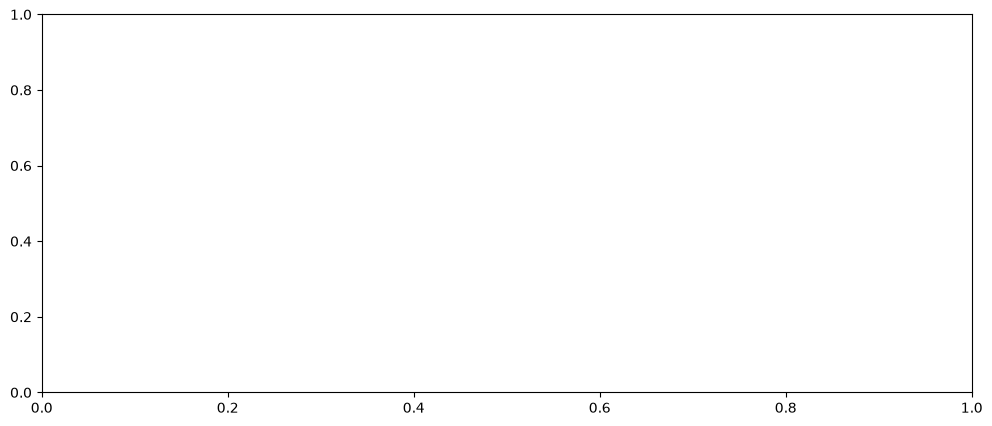

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

window_size = 500

fig, ax = plt.subplots(figsize=(12,6))
fig.subplots_adjust(bottom=0.25)



# Plot the initial 500 days
(line,) = ax.plot(stocks_x_axis, stocks_x_axis, color='#1f77b4', lw=1.5, label='Stock Price')

# Set strict Y-limits since your data is already normalized between 0 and 1
ax.set_ylim(-0.05, 1.05)
# Set the initial X-axis view (0 to 500)
ax.set_xlim(0, window_size)

# Add titles and grid labels
ax.set_title(
    'Single Company Stock Price - 20,000 Day Timeline',
    fontsize=14,
    pad=15,
    weight='bold',
)
ax.set_xlabel('Timeline (Days)', fontsize=11)
ax.set_ylabel('Normalized Price (0.0 - 1.0)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# 4. Create the slider axis [left, bottom, width, height] and the Slider widget
ax_slider = plt.axes([0.2, 0.08, 0.65, 0.04])
slider = Slider(
    ax_slider,
    label='Scroll Timeline ',
    valmin=0,
    valmax=stocks_x_axis - window_size,
    valinit=0,
    valstep=50,  # Moves by 50 days per click on the slider bar
    valfmt='%0.0f',
    color='#2ca02c',
)


# 5. Define what happens when the slider moves
def update_window(val):
  # Get the current slider position
  start_day = int(slider.val)

  # Shift the X-axis view window dynamically
  ax.set_xlim(start_day, start_day + window_size)

  # Redraw the canvas cleanly
  fig.canvas.draw_idle()


# Connect the slider to the update function
slider.on_changed(update_window)

plt.show()